# NIR White Lagkitan Corn (Three-Class)

In [49]:
import pandas as pd
import numpy as np

## Load Data

In [50]:
df_raw_data = pd.read_csv('appendix_raw_dataset1.csv')
df_raw_data

,Class,730nm,760nm,810nm,860nm,900nm,940nm,Sample No.,Brix (%)
0,Average,235.264008,165.100433,368.587189,2455.738037,107.280037,45.421616,1,5.8
1,Average,221.472671,156.633743,346.383148,2311.896973,126.659653,49.371319,2,4.2
2,Average,245.810333,171.873779,347.271301,2354.817383,109.356422,41.471909,3,3.6
3,Bland,257.167908,177.800476,379.245117,2474.298340,116.277718,41.471909,4,3.0
4,Bland,219.850159,151.553726,332.172546,2170.375977,112.817070,44.434189,5,2.6
...,...,...,...,...,...,...,...,...,...
195,Sweet,279.883057,194.733841,393.455719,2310.737061,137.733719,57.270733,196,9.4
196,Average,268.525482,177.800476,377.468811,2264.336670,119.738358,46.409042,197,8.0
197,Average,270.959228,188.807159,381.021454,2520.698486,117.661972,46.409042,198,7.0
198,Average,272.581757,188.807159,394.343872,2528.818604,116.277718,48.383892,199,6.2


## Preprocessing

In [51]:
feature_cols = ['730nm', '760nm', '810nm', '860nm', '900nm', '940nm']

### SNV
Standard Normal Variate normalization.

In [52]:
df_snv = df_raw_data.copy()

def snv_row(x):
    x = x.astype(float)
    mean = x.mean()
    std = x.std(ddof=1)

    if std < 1e-8:
        return x * np.nan

    return (x - mean) / std

df_snv[feature_cols] = df_snv[feature_cols].apply(
    snv_row, axis=1, result_type='expand'
)

df_snv = df_snv.dropna()

## Plot

### Mean Spectra
Plot the average spectra of each class.

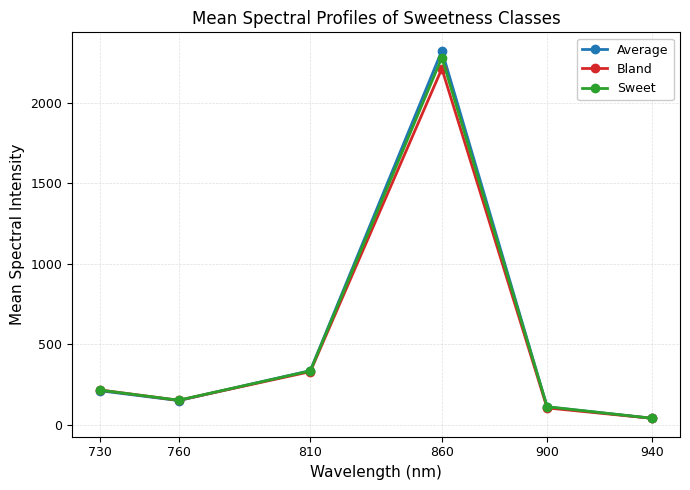

In [53]:
import matplotlib.pyplot as plt

mean_spectra = df_raw_data.groupby('Class')[feature_cols].mean()

wavelengths = [730, 760, 810, 860, 900, 940]

class_colors = {
    'Bland': '#d62728',
    'Average': '#1f77b4',
    'Sweet': '#2ca02c'
}

fig, ax = plt.subplots(figsize=(7, 5))

for cls in mean_spectra.index:
    ax.plot(
        wavelengths,
        mean_spectra.loc[cls],
        marker='o',
        markersize=6,
        linewidth=2,
        color=class_colors[cls],
        label=cls
    )

ax.set_xlabel('Wavelength (nm)', fontsize=11)
ax.set_ylabel('Mean Spectral Intensity', fontsize=11)
ax.set_title('Mean Spectral Profiles of Sweetness Classes', fontsize=12)

ax.set_xticks(wavelengths)

ax.legend(
    fontsize=9,
    frameon=True,
    framealpha=1
)

ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)

ax.tick_params(labelsize=9)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.tight_layout()
#plt.savefig('mean_spectra.png', dpi=600, bbox_inches='tight')
plt.show()

### PCA

In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X0 = df_snv[feature_cols]
y0 = df_snv['Class']

# Standardize the six wavelength features before PCA
X_scaled0 = StandardScaler().fit_transform(X0)

# Reduce to two principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled0)

# Explained variance
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

print(f"PC1 explained variance: {pc1_var:.2f}%")
print(f"PC2 explained variance: {pc2_var:.2f}%")
print(f"Total PC1 + PC2: {pc1_var + pc2_var:.2f}%")

PC1 explained variance: 85.88%
PC2 explained variance: 10.60%
Total PC1 + PC2: 96.48%


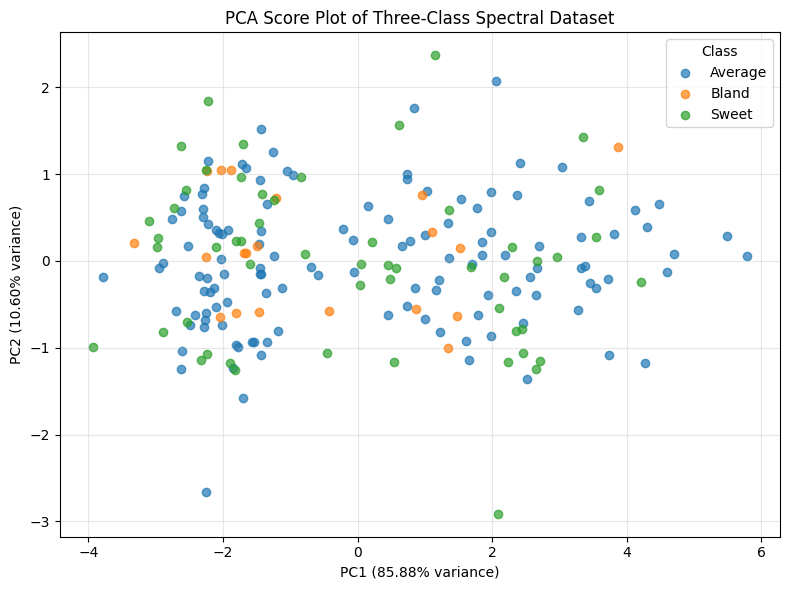

In [55]:
plt.figure(figsize=(8, 6))

for class_name in y0.unique():
    mask = y0 == class_name

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=class_name,
        alpha=0.7
    )

plt.xlabel(f'PC1 ({pc1_var:.2f}% variance)')
plt.ylabel(f'PC2 ({pc2_var:.2f}% variance)')
plt.title('PCA Score Plot of Three-Class Spectral Dataset')
plt.legend(title='Class')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Data Preparation

### Selecting Features (X) and Targets (y)

In [56]:
X = df_snv[feature_cols]
y = df_snv['Class'].map({'Bland': 0, 'Average': 1, 'Sweet': 2})

### Data Split

In [57]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

## Optuna Hyperparameter Tuning

In [58]:
import optuna
from sklearn.model_selection import cross_val_score, RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier

# For reproducibility
sampler = optuna.samplers.TPESampler(seed=42)
inner_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# Tune to penalize instability
alpha = 0.5
stability_std_cap = 0.02

### Logistic Regression

In [59]:
def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.03, 3.0, log=True),

        'solver': 'lbfgs',

        'penalty': 'l2',

        'class_weight': trial.suggest_categorical(
            'class_weight',
            [None, 'balanced']
        ),

        'tol': trial.suggest_float('tol', 1e-5, 1e-4, log=True),
        'max_iter': 5000,
        'random_state': 42
    }

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=inner_cv,
        scoring='f1_macro'
    )

    mean_score = score.mean()
    std_score = score.std()

    return mean_score - alpha * min(std_score, stability_std_cap)

In [60]:
study_lr = optuna.create_study(direction='maximize', sampler=sampler)
study_lr.optimize(objective_lr, n_trials=100)

study_lr.best_params, study_lr.best_value

[I 2026-09-10 20:31:28,722] A new study created in memory with name: no-name-f6079869-702c-43b8-bb1c-a8541af4e5a8
C:\Users\Lorine Jane\PycharmProjects\Thesis 2nd Final Testing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Lorine Jane\PycharmProjects\Thesis 2nd Final Testing\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Use

({'C': 1.184853530094305,
  'class_weight': 'balanced',
  'tol': 1.3853621181268501e-05},
 0.344730214138147)

### Random Forest

In [61]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'max_features': trial.suggest_categorical(
            'max_features',
            ['sqrt', 0.5, 0.8]
        ),
        'min_samples_split': trial.suggest_int('min_samples_split', 4, 12),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 6),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 40),
        'class_weight': trial.suggest_categorical(
            'class_weight',
            [None, 'balanced']
        ),

        'bootstrap': True,
        'n_jobs': -1,
        'random_state': 42
    }

    model = Pipeline([
        ('clf', RandomForestClassifier(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=inner_cv,
        scoring='f1_macro'
    )

    mean_score = score.mean()
    std_score = score.std()

    return mean_score - alpha * min(std_score, stability_std_cap)

In [62]:
study_rf = optuna.create_study(direction='maximize', sampler=sampler)
study_rf.optimize(objective_rf, n_trials=100)

study_rf.best_params, study_rf.best_value

[I 2026-09-10 20:32:03,373] A new study created in memory with name: no-name-c94fbb02-2ddc-46fb-994f-3ca92a5951b6
[I 2026-09-10 20:32:08,578] Trial 0 finished with value: 0.2930257551558529 and parameters: {'n_estimators': 168, 'max_depth': 4, 'max_features': 0.5, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_leaf_nodes': 26, 'class_weight': None}. Best is trial 0 with value: 0.2930257551558529.
[I 2026-09-10 20:32:17,739] Trial 1 finished with value: 0.3464504257350856 and parameters: {'n_estimators': 296, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_leaf_nodes': 16, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.3464504257350856.
[I 2026-09-10 20:32:24,432] Trial 2 finished with value: 0.31514621142762483 and parameters: {'n_estimators': 208, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_leaf_nodes': 34, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.34645042573

({'n_estimators': 223,
  'max_depth': 6,
  'max_features': 'sqrt',
  'min_samples_split': 11,
  'min_samples_leaf': 1,
  'max_leaf_nodes': 24,
  'class_weight': 'balanced'},
 0.3634368761381146)

### Linear Discriminant Analysis

In [63]:
def objective_lda(trial):
    params = {
    'solver': trial.suggest_categorical(
        'solver',
        ['lsqr', 'eigen']
    ),
    'shrinkage': trial.suggest_float(
        'shrinkage',
        0.01,
        0.5,
        log=True
    ),
    'store_covariance': False,
    'tol': trial.suggest_float(
        'tol',
        1e-4,
        1e-2,
        log=True
    )
    }

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearDiscriminantAnalysis(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=inner_cv,
        scoring='f1_macro'
    )

    mean_score = score.mean()
    std_score = score.std()

    return mean_score - alpha * min(std_score, stability_std_cap)

In [64]:
study_lda = optuna.create_study(direction='maximize', sampler=sampler)
study_lda.optimize(objective_lda, n_trials=100)

study_lda.best_params, study_lda.best_value

[I 2026-09-10 20:44:08,194] A new study created in memory with name: no-name-b9269bda-b839-4e41-9491-2dfe39e32530
[I 2026-09-10 20:44:08,458] Trial 0 finished with value: 0.24861713415471415 and parameters: {'solver': 'lsqr', 'shrinkage': 0.06995363653959079, 'tol': 0.0003997206819121809}. Best is trial 0 with value: 0.24861713415471415.
[I 2026-09-10 20:44:08,708] Trial 1 finished with value: 0.24861713415471415 and parameters: {'solver': 'lsqr', 'shrinkage': 0.1085504227474508, 'tol': 0.0010124137770478635}. Best is trial 0 with value: 0.24861713415471415.
[I 2026-09-10 20:44:08,963] Trial 2 finished with value: 0.251598041291377 and parameters: {'solver': 'eigen', 'shrinkage': 0.34923398229690455, 'tol': 0.00030138649046798047}. Best is trial 2 with value: 0.251598041291377.
[I 2026-09-10 20:44:09,236] Trial 3 finished with value: 0.2531922726574767 and parameters: {'solver': 'eigen', 'shrinkage': 0.472705392113142, 'tol': 0.000304867088345807}. Best is trial 3 with value: 0.2531922

({'solver': 'eigen',
  'shrinkage': 0.02097323021406705,
  'tol': 0.002894530120037453},
 0.27133951743995566)

### Support Vector Machine

In [65]:
def objective_svc(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 50.0, log=True),

        'kernel': trial.suggest_categorical(
            'kernel',
            ['linear', 'rbf']
        ),

        'gamma': trial.suggest_categorical(
            'gamma',
            ['scale', 'auto']
        ),

        'class_weight': trial.suggest_categorical(
            'class_weight',
            [None, 'balanced']
        ),

        'tol': trial.suggest_float(
            'tol',
            1e-5,
            1e-3,
            log=True
        ),

        'random_state': 42
    }

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=inner_cv,
        scoring='f1_macro'
    )

    mean_score = score.mean()
    std_score = score.std()

    return mean_score - alpha * min(std_score, stability_std_cap)

In [66]:
study_svc = optuna.create_study(direction='maximize', sampler=sampler)
study_svc.optimize(objective_svc, n_trials=100)

study_svc.best_params, study_svc.best_value

[I 2026-09-10 20:44:25,942] A new study created in memory with name: no-name-3ce5e554-45b8-40b6-9672-45a142f8eab7
[I 2026-09-10 20:44:26,100] Trial 0 finished with value: 0.18038175590619585 and parameters: {'C': 0.18263928656552764, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.00012894414393074176}. Best is trial 0 with value: 0.18038175590619585.
[I 2026-09-10 20:44:26,255] Trial 1 finished with value: 0.25505360023195073 and parameters: {'C': 0.9102519167536312, 'kernel': 'linear', 'gamma': 'auto', 'class_weight': None, 'tol': 4.993662066506419e-05}. Best is trial 1 with value: 0.25505360023195073.
[I 2026-09-10 20:44:26,442] Trial 2 finished with value: 0.32724039952721273 and parameters: {'C': 4.844938633680331, 'kernel': 'linear', 'gamma': 'scale', 'class_weight': 'balanced', 'tol': 0.0006267702540388485}. Best is trial 2 with value: 0.32724039952721273.
[I 2026-09-10 20:44:26,694] Trial 3 finished with value: 0.25575002863577784 and parameters: {'C': 1

({'C': 7.439141139254955,
  'kernel': 'rbf',
  'gamma': 'auto',
  'class_weight': 'balanced',
  'tol': 1.7380404144747442e-05},
 0.3362407319227973)

### XGBoost

In [67]:
def objective_xgb(trial):
    params = {
        'max_depth': trial.suggest_int('max_depth', 2, 4),

        'learning_rate': trial.suggest_float(
            'learning_rate',
            0.01,
            0.1,
            log=True
        ),

        'n_estimators': trial.suggest_int('n_estimators', 100, 300),

        'min_child_weight': trial.suggest_float(
            'min_child_weight',
            1.0,
            10.0
        ),

        'gamma': trial.suggest_float(
            'gamma',
            0.0,
            0.5
        ),

        'subsample': trial.suggest_float(
            'subsample',
            0.7,
            1.0
        ),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree',
            0.7,
            1.0
        ),

        'reg_lambda': trial.suggest_float(
            'reg_lambda',
            0.5,
            10.0,
            log=True
        ),

        'reg_alpha': trial.suggest_float(
            'reg_alpha',
            0.0,
            0.5
        ),

        'max_delta_step': trial.suggest_int(
            'max_delta_step',
            0,
            5
        ),

        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'random_state': 42,
        'n_jobs': -1
    }

    model = Pipeline([
        ('clf', XGBClassifier(**params))
    ])

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=inner_cv,
        scoring='f1_macro'
    )

    mean_score = score.mean()
    std_score = score.std()

    return mean_score - alpha * min(std_score, stability_std_cap)

In [ ]:
study_xgb = optuna.create_study(direction='maximize', sampler=sampler)
study_xgb.optimize(objective_xgb, n_trials=100)

study_xgb.best_params, study_xgb.best_value

[I 2026-09-10 20:45:33,945] A new study created in memory with name: no-name-a0079521-3207-4ee9-9c58-68a63f47b1bc
[I 2026-09-10 20:45:36,363] Trial 0 finished with value: 0.29129214919454843 and parameters: {'max_depth': 3, 'learning_rate': 0.09773584004575739, 'n_estimators': 128, 'min_child_weight': 5.664966871273631, 'gamma': 0.4386865359639777, 'subsample': 0.9222305853262613, 'colsample_bytree': 0.9091047222985804, 'reg_lambda': 4.101312569988357, 'reg_alpha': 0.17974557560987758, 'max_delta_step': 1}. Best is trial 0 with value: 0.29129214919454843.
[I 2026-09-10 20:45:41,107] Trial 1 finished with value: 0.2538965202776887 and parameters: {'max_depth': 4, 'learning_rate': 0.06458228319438214, 'n_estimators': 274, 'min_child_weight': 9.219164973008242, 'gamma': 0.2556711994304689, 'subsample': 0.8504548884061598, 'colsample_bytree': 0.9394885536900326, 'reg_lambda': 3.5042297663646855, 'reg_alpha': 0.3509834386288517, 'max_delta_step': 4}. Best is trial 0 with value: 0.2912921491

## Validation Set Metrics
Performance test of each model. Only one will be selected based on the results here.

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [38]:
models_val = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(**study_lr.best_params)),
    ]),

    'Random Forest': RandomForestClassifier(**study_rf.best_params),

    'LDA': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearDiscriminantAnalysis(**study_lda.best_params)),
    ]),

    'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(**study_svc.best_params)),
    ]),

    'XGBoost': XGBClassifier(**study_xgb.best_params)
}

In [39]:
val_predictions = {}
val_metrics = {}
val_reports ={}

for model_name, model in models_val.items():

    model.fit(X_train, y_train)

    val_predictions[model_name] = model.predict(X_val)

    val_metrics[model_name] = {
        'Accuracy': accuracy_score(y_val, val_predictions[model_name]),
        'Precision': precision_score(y_val, val_predictions[model_name], average='weighted', zero_division=0),
        'Recall': recall_score(y_val, val_predictions[model_name], average='weighted', zero_division=0),
        'F1': f1_score(y_val, val_predictions[model_name], average='weighted', zero_division=0),
    }

    val_reports[model_name] = classification_report(y_val, val_predictions[model_name], zero_division=0)

### Summary Metrics

In [40]:
df_val_metrics = pd.DataFrame(val_metrics)
df_val_metrics.T.sort_values(by='Accuracy', ascending=False)

,Accuracy,Precision,Recall,F1
XGBoost,0.733333,0.669333,0.733333,0.682284
LDA,0.633333,0.401111,0.633333,0.491156
Random Forest,0.633333,0.610000,0.633333,0.621368
SVC,0.466667,0.528889,0.466667,0.491068
Logistic Regression,0.266667,0.421329,0.266667,0.276781


### Classification Report

In [41]:
for model_names, reports in val_reports.items():
    print(f'{model_names}:\n {reports} \n -------------------------------------------------------')

Logistic Regression:
               precision    recall  f1-score   support

           0       0.08      0.33      0.12         3
           1       0.50      0.16      0.24        19
           2       0.36      0.50      0.42         8

    accuracy                           0.27        30
   macro avg       0.31      0.33      0.26        30
weighted avg       0.42      0.27      0.28        30
 
 -------------------------------------------------------
Random Forest:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.70      0.74      0.72        19
           2       0.62      0.62      0.62         8

    accuracy                           0.63        30
   macro avg       0.44      0.45      0.45        30
weighted avg       0.61      0.63      0.62        30
 
 -------------------------------------------------------
LDA:
               precision    recall  f1-score   support

           0       0.00

### Confusion Matrices

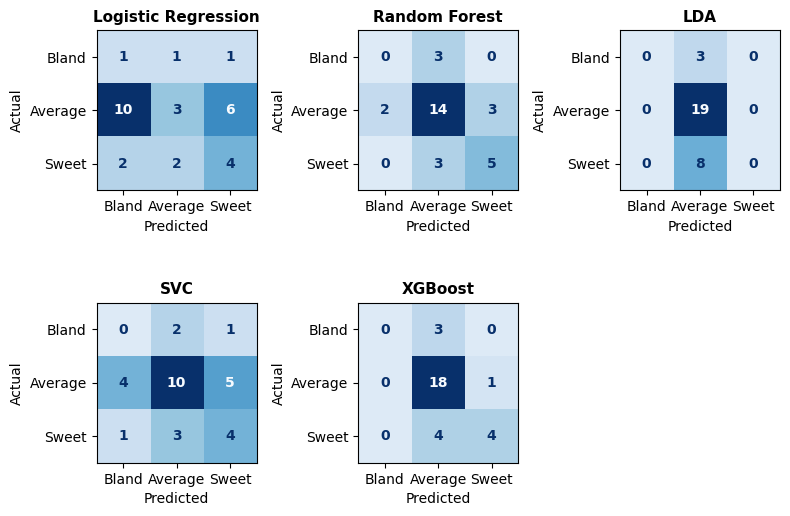

In [42]:
import math

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

cm = {}

class_names = ['Bland', 'Average', 'Sweet']

for model_name, pred in val_predictions.items():
    cm[model_name] = confusion_matrix(y_val, pred)

n_models = len(cm)

n_cols = 3
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(8, 2.8 * n_rows),
    facecolor='white'
)

axes = axes.flatten()

for ax, (model_name, matrix) in zip(axes, cm.items()):

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        colorbar=False,
        values_format='d',
        im_kw={
            'vmin': -0.15 * matrix.max(),
            'vmax': matrix.max()
        }
    )

    ax.set_title(model_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    ax.grid(False)

    for text in ax.texts:
        text.set_fontsize(10)
        text.set_fontweight('bold')

for ax in axes[n_models:]:
    fig.delaxes(ax)

plt.tight_layout()

# plt.savefig(
#     'val_cm_fig1.png',
#     dpi=600,
#     bbox_inches='tight',
#     facecolor='white'
# )

plt.show()

## Test Set Metrics
Performance test of the selected model.

In [43]:
X_combined = np.concatenate([X_train, X_val], axis=0)
y_combined = np.concatenate([y_train, y_val], axis=0)

In [44]:
final_model = XGBClassifier(**study_xgb.best_params)
final_model.fit(X_combined, y_combined)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8097002223699291
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

In [45]:
test_predictions = final_model.predict(X_test)

test_metrics = {
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, test_predictions),
    'Precision': precision_score(y_test, test_predictions, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, test_predictions, average='weighted', zero_division=0),
    'F1': f1_score(y_test, test_predictions, average='weighted', zero_division=0),
}

### Summary Metrics

In [46]:
df_test_metrics = pd.DataFrame([test_metrics])
df_test_metrics

,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.533333,0.533333,0.533333,0.533333


### Classification Report

In [47]:
print(classification_report(y_test, test_predictions))

              precision    recall  f1-score   support

           0       0.33      0.33      0.33         3
           1       0.68      0.68      0.68        19
           2       0.25      0.25      0.25         8

    accuracy                           0.53        30
   macro avg       0.42      0.42      0.42        30
weighted avg       0.53      0.53      0.53        30



### Confusion Matrix

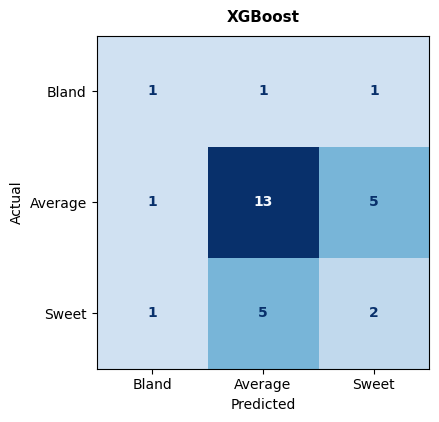

In [48]:
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

cm1 = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(
    figsize=(4.5, 4.5),
    facecolor='white'
)

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm1,
    display_labels=class_names
)

disp1.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False,
    values_format='d',
    im_kw={
        'vmin': -0.15 * cm1.max(),
        'vmax': cm1.max()
    }
)

ax.set_title('XGBoost', fontsize=11, fontweight='bold', pad=10)
ax.set_xlabel('Predicted', fontsize=10)
ax.set_ylabel('Actual', fontsize=10)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

ax.grid(False)

for text in ax.texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])

# plt.savefig(
#     'test_cm_fig1.png',
#     dpi=600,
#     bbox_inches='tight',
#     facecolor='white'
# )

plt.show()